# Candidate Detection Method 1: Surface Clues

Implements a simple first-pass candidate detector. It does not need a GPU and should be finishable in one work session. The goal is to generate possible slang/specialized terms, score them with simple signals, plot the results, and inspect what the method gets right or wrong.

This method uses:

**Surface score**: does the candidate look unusual, rare, symbolic, acronym-like, emoji-like, or nonstandard?

This is just the first baseline. It should catch obvious terms and give us a clean place to start improving.

In [ ]:
# Install lightweight packages for Candidate Detection Method 1.
# No GPU is needed.
!pip -q install regex emoji wordfreq rapidfuzz scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.1/183.1 kB 14.7 MB/s eta 0:00:00


In [ ]:
import json
import math
import os
from collections import Counter

from datasets import load_dataset
import emoji
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import regex as re
from rapidfuzz import fuzz
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
from wordfreq import zipf_frequency

In [ ]:
# Use the dataframe you already created earlier in the notebook.
# If df is not available, this will load the dataset again.
try:
    df
except NameError:
    from datasets import load_dataset
    data_slang = load_dataset("acader/genz-alpha-slangs")
    df = pd.DataFrame(data_slang["train"])

required_cols = {"Sentence", "Translation", "Explanation"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print(df.shape)
df[["Sentence", "Translation", "Explanation"]].head(3)

(5000, 4)


,Sentence,Translation,Explanation
0,"Mate, IRL you fold faster than a Walmart chair...",In real life you give up or back down faster t...,"**""fold""**: give up or back down. - **""IRL""**:..."
1,"Homie, this vibe is straight mid 😩 🫠🔥",This vibe is straight average or unimpressive 😩.,"**""mid""**: average or unimpressive. - **""🔥""**:..."
2,"Bro, you ghosted again 😭💀 💎😤",You ignored or didn’t show up again.,"**""ghosted""**: ignored or didn’t show up. - **..."


In [ ]:
# Helpers: normalization, gold-term extraction, tokenization, and candidate generation.

def is_emoji(text):
    return any(ch in emoji.EMOJI_DATA for ch in str(text))

def remove_emoji_gold_terms(term_list):
    return [t for t in term_list if not is_emoji(t)]

def normalize_term(text):
    text = str(text).lower().strip()
    text = re.sub(r"^[^\p{L}\p{N}]+|[^\p{L}\p{N}]+$", "", text)
    text = re.sub(r"\s+", " ", text)
    return text


def extract_gold_terms(explanation):
    """Extract labeled slang terms from the Explanation column.
    This is for evaluation only, not for scoring.
    """
    if not isinstance(explanation, str):
        return []
    terms = re.findall(r'\*\*"([^"]+)"\*\*:', explanation)
    if not terms:
        terms = re.findall(r'"([^"]+)"\s*:', explanation)
    return [t.strip() for t in terms if t.strip()]


TOKEN_RE = re.compile(r"[\p{L}\p{M}]+(?:['’\-][\p{L}\p{M}]+)?|[\p{N}]+|[#@][\p{L}\p{N}_]+|[^\s]")


def tokenize(text):
    return [m.group(0) for m in TOKEN_RE.finditer(str(text))]


def is_only_punctuation(text):
    return not bool(re.search(r"[\p{L}\p{N}]", str(text)))


def generate_candidates(text, max_n=4):
    toks = tokenize(text)
    rows = []
    for n in range(1, max_n + 1):
        for i in range(len(toks) - n + 1):
            cand = " ".join(toks[i:i+n]).strip()
            if "," in cand:
                continue
            if is_emoji(cand):
                continue
            norm = normalize_term(cand)
            if not norm:
                continue
            if is_only_punctuation(cand):
                continue
            rows.append({"candidate": cand, "candidate_norm": norm})
    return rows


def is_gold_candidate(candidate_norm, gold_norms):
    for g in gold_norms:
        if not g:
            continue
        if candidate_norm == g:
            return 1
        # loose match helps when punctuation/plurals differ slightly
        if fuzz.ratio(candidate_norm, g) >= 92:
            return 1
    return 0


df["gold_terms"] = df["Explanation"].apply(extract_gold_terms).apply(remove_emoji_gold_terms)
df["gold_norms"] = df["gold_terms"].apply(lambda xs: [normalize_term(x) for x in xs if normalize_term(x)])

df[["Sentence", "gold_terms"]].head(5)

,Sentence,gold_terms
0,"Mate, IRL you fold faster than a Walmart chair...","[fold, IRL]"
1,"Homie, this vibe is straight mid 😩 🫠🔥",[mid]
2,"Bro, you ghosted again 😭💀 💎😤",[ghosted]
3,"Homie, pull up or stay sus 🫡💀 💀",[sus]
4,"Bro, skibidi outta here, sigma style 🗿🔥 🫠",[skibidi outta here]


In [ ]:
# Debug emojis as gold terms
emoji_golds = []

for terms in df["gold_terms"]:
    for t in terms:
        if is_emoji(t):
            emoji_golds.append(t)

print("Emoji gold terms:", len(emoji_golds))

Emoji gold terms: 0


In [ ]:
# Build candidate rows from the Sentence column.
records = []
for doc_id, row in df.reset_index(drop=True).iterrows():
    gold_norms = row["gold_norms"]
    for cand in generate_candidates(row["Sentence"], max_n=4):
        cand_norm = cand["candidate_norm"]
        records.append({
            "doc_id": doc_id,
            "sentence": row["Sentence"],
            "translation": row["Translation"],
            "candidate": cand["candidate"],
            "candidate_norm": cand_norm,
            "gold_terms": row["gold_terms"],
            "is_gold": is_gold_candidate(cand_norm, gold_norms),
        })

cand_df = pd.DataFrame(records).drop_duplicates(["doc_id", "candidate_norm"])
print(cand_df.shape)
cand_df.head(10)

(51151, 7)


,doc_id,sentence,translation,candidate,candidate_norm,gold_terms,is_gold
0,0,"Mate, IRL you fold faster than a Walmart chair...",In real life you give up or back down faster t...,Mate,mate,"[fold, IRL]",0
1,0,"Mate, IRL you fold faster than a Walmart chair...",In real life you give up or back down faster t...,IRL,irl,"[fold, IRL]",1
2,0,"Mate, IRL you fold faster than a Walmart chair...",In real life you give up or back down faster t...,you,you,"[fold, IRL]",0
3,0,"Mate, IRL you fold faster than a Walmart chair...",In real life you give up or back down faster t...,fold,fold,"[fold, IRL]",1
4,0,"Mate, IRL you fold faster than a Walmart chair...",In real life you give up or back down faster t...,faster,faster,"[fold, IRL]",0
5,0,"Mate, IRL you fold faster than a Walmart chair...",In real life you give up or back down faster t...,than,than,"[fold, IRL]",0
6,0,"Mate, IRL you fold faster than a Walmart chair...",In real life you give up or back down faster t...,a,a,"[fold, IRL]",0
7,0,"Mate, IRL you fold faster than a Walmart chair...",In real life you give up or back down faster t...,Walmart,walmart,"[fold, IRL]",0
8,0,"Mate, IRL you fold faster than a Walmart chair...",In real life you give up or back down faster t...,chair,chair,"[fold, IRL]",0
9,0,"Mate, IRL you fold faster than a Walmart chair...",In real life you give up or back down faster t...,IRL you,irl you,"[fold, IRL]",0


In [ ]:
# Quick check: did the candidate generator include most of the labeled terms?
gold_total = sum(len(x) for x in df["gold_norms"])
covered = 0
missing_examples = []

for doc_id, row in df.reset_index(drop=True).iterrows():
    generated = set(cand_df.loc[cand_df["doc_id"] == doc_id, "candidate_norm"])
    for g in row["gold_norms"]:
        if g in generated:
            covered += 1
        else:
            missing_examples.append((doc_id, g, row["Sentence"]))

print(f"Gold terms covered by candidate generator: {covered}/{gold_total}")
print("Missing examples:")
missing_examples[:10]

Gold terms covered by candidate generator: 6998/6998
Missing examples:


[]

In [ ]:
# Surface score: simple features that make a candidate look unusual.

def term_zipf(term):
    words = [w for w in re.findall(r"[\p{L}]+", str(term).lower())]
    if not words:
        return 0.0
    # Use the rarest word in a phrase. This keeps phrases like "skibidi rizz" rare.
    return min(zipf_frequency(w, "en") for w in words)


def surface_features(candidate):
    text = str(candidate).strip()
    lower = text.lower()
    zipf = term_zipf(text)
    return {
        "zipf": zipf,
        "rare_or_unknown": int(zipf == 0 or zipf < 3.0),
        "is_acronym": int(bool(re.fullmatch(r"[A-Z]{2,}", text))),
        "has_digit": int(bool(re.search(r"\p{N}", text))),
        "has_symbol": int(bool(re.search(r"[^\p{L}\p{N}\s'’\-]", text))),
        "has_repeated_char": int(bool(re.search(r"(.){2,}", lower))),
        "num_words": len(text.split()),
    }


def surface_score(features):
    raw = (
        1.5 * features["rare_or_unknown"]
        + 1.0 * features["is_acronym"]
        + 0.5 * features["has_digit"]
        + 0.5 * features["has_symbol"]
        + 0.5 * features["has_repeated_char"]
    )
    return min(raw / 3.5, 1.0)

feat_rows = cand_df["candidate"].apply(surface_features).apply(pd.Series)
cand_df = pd.concat([cand_df.reset_index(drop=True), feat_rows.reset_index(drop=True)], axis=1)
cand_df["surface_score"] = cand_df.apply(lambda r: surface_score(r), axis=1)

cand_df[["candidate", "zipf", "rare_or_unknown", "is_acronym", "surface_score", "is_gold"]].head(10)

,candidate,zipf,rare_or_unknown,is_acronym,surface_score,is_gold
0,Mate,4.55,0.0,0.0,0.000000,0
1,IRL,3.43,0.0,1.0,0.285714,1
2,you,6.98,0.0,0.0,0.000000,0
3,fold,4.08,0.0,0.0,0.000000,1
4,faster,4.64,0.0,0.0,0.000000,0
5,than,6.13,0.0,0.0,0.000000,0
6,a,7.36,0.0,0.0,0.000000,0
7,Walmart,3.95,0.0,0.0,0.000000,0
8,chair,4.69,0.0,0.0,0.000000,0
9,IRL you,3.43,0.0,0.0,0.000000,0


In [ ]:
# Method 1 score: surface cues only.
# Corpus score has been removed from this method.

cand_df["method1_score"] = cand_df["surface_score"]

cand_df[["candidate", "surface_score", "method1_score", "is_gold"]].sort_values("method1_score", ascending=False).head(15)



,candidate,surface_score,method1_score,is_gold
42318,lowkey annoyed,0.428571,0.428571,0
42317,stop cappin,0.428571,0.428571,0
42315,lowkey,0.428571,0.428571,1
42314,cappin,0.428571,0.428571,1
42311,skibidi outta here,0.428571,0.428571,1
42308,skibidi outta,0.428571,0.428571,0
10237,lowkey,0.428571,0.428571,1
10238,flexin,0.428571,0.428571,1
10239,lowkey flexin,0.428571,0.428571,0
42303,skibidi,0.428571,0.428571,0


In [ ]:
# Evaluate precision, recall, and F1 at several thresholds.
thresholds = np.round(np.arange(0.10, 0.71, 0.10), 2)
rows = []

y_true = cand_df["is_gold"].astype(int).values
for th in thresholds:
    y_pred = (cand_df["method1_score"] >= th).astype(int).values
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    rows.append({"threshold": th, "precision": p, "recall": r, "f1": f1, "predicted_count": int(y_pred.sum())})

threshold_results = pd.DataFrame(rows)
threshold_results

,threshold,precision,recall,f1,predicted_count
0,0.1,0.468056,0.497285,0.482228,7435
1,0.2,0.468056,0.497285,0.482228,7435
2,0.3,0.430853,0.427837,0.429340,6949
3,0.4,0.430853,0.427837,0.429340,6949
4,0.5,0.000000,0.000000,0.000000,0
5,0.6,0.000000,0.000000,0.000000,0
6,0.7,0.000000,0.000000,0.000000,0


In [ ]:
# Additional candidate-type-specific gold comparisons.
# Phrase candidates are compared only against gold phrases.
# Word candidates are compared only against gold words.

gold_word_norms_by_doc = df["gold_norms"].apply(
    lambda xs: [g for g in xs if len(str(g).split()) == 1]
)
gold_phrase_norms_by_doc = df["gold_norms"].apply(
    lambda xs: [g for g in xs if len(str(g).split()) > 1]
)

def gold_word_label(row):
    gold_word_norms = gold_word_norms_by_doc.iloc[int(row["doc_id"])]
    return is_gold_candidate(row["candidate_norm"], gold_word_norms)

def gold_phrase_label(row):
    gold_phrase_norms = gold_phrase_norms_by_doc.iloc[int(row["doc_id"])]
    return is_gold_candidate(row["candidate_norm"], gold_phrase_norms)

cand_df["is_gold_word_only"] = cand_df.apply(gold_word_label, axis=1)
cand_df["is_gold_phrase_only"] = cand_df.apply(gold_phrase_label, axis=1)

phrase_candidates_df = cand_df[cand_df["num_words"] > 1].copy()
word_candidates_df = cand_df[cand_df["num_words"] == 1].copy()

def evaluate_thresholds(eval_df, label_col):
    rows = []
    y_true = eval_df[label_col].astype(int).values
    for th in thresholds:
        y_pred = (eval_df["method1_score"] >= th).astype(int).values
        p, r, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="binary", zero_division=0
        )
        rows.append({
            "threshold": th,
            "precision": p,
            "recall": r,
            "f1": f1,
            "predicted_count": int(y_pred.sum()),
            "gold_count": int(y_true.sum()),
            "candidate_count": int(len(y_true)),
        })
    return pd.DataFrame(rows)

phrase_candidates_gold_phrases_results = evaluate_thresholds(
    phrase_candidates_df, "is_gold_phrase_only"
)
word_candidates_gold_words_results = evaluate_thresholds(
    word_candidates_df, "is_gold_word_only"
)

print("Phrase candidates vs gold phrases")
display(phrase_candidates_gold_phrases_results)

print("Word candidates vs gold words")
display(word_candidates_gold_words_results)


Phrase candidates vs gold phrases


,threshold,precision,recall,f1,predicted_count,gold_count,candidate_count
0,0.1,0.126422,0.334448,0.183486,3955,1495,26243
1,0.2,0.126422,0.334448,0.183486,3955,1495,26243
2,0.3,0.126422,0.334448,0.183486,3955,1495,26243
3,0.4,0.126422,0.334448,0.183486,3955,1495,26243
4,0.5,0.000000,0.000000,0.000000,0,1495,26243
5,0.6,0.000000,0.000000,0.000000,0,1495,26243
6,0.7,0.000000,0.000000,0.000000,0,1495,26243


Word candidates vs gold words


,threshold,precision,recall,f1,predicted_count,gold_count,candidate_count
0,0.1,0.856322,0.541523,0.663475,3480,5503,24908
1,0.2,0.856322,0.541523,0.663475,3480,5503,24908
2,0.3,0.832999,0.453207,0.587031,2994,5503,24908
3,0.4,0.832999,0.453207,0.587031,2994,5503,24908
4,0.5,0.000000,0.000000,0.000000,0,5503,24908
5,0.6,0.000000,0.000000,0.000000,0,5503,24908
6,0.7,0.000000,0.000000,0.000000,0,5503,24908


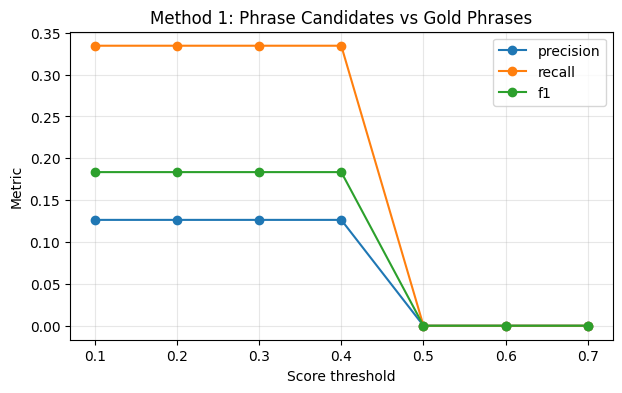

In [ ]:
# Plot: phrase candidates compared only against gold phrases.
plt.figure(figsize=(7, 4))
plt.plot(phrase_candidates_gold_phrases_results["threshold"], phrase_candidates_gold_phrases_results["precision"], marker="o", label="precision")
plt.plot(phrase_candidates_gold_phrases_results["threshold"], phrase_candidates_gold_phrases_results["recall"], marker="o", label="recall")
plt.plot(phrase_candidates_gold_phrases_results["threshold"], phrase_candidates_gold_phrases_results["f1"], marker="o", label="f1")
plt.xlabel("Score threshold")
plt.ylabel("Metric")
plt.title("Method 1: Phrase Candidates vs Gold Phrases")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


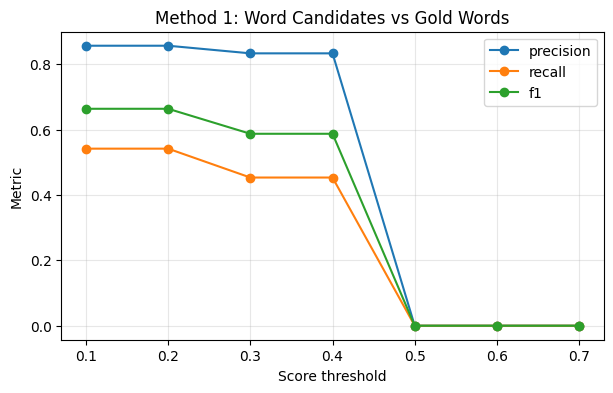

In [ ]:
# Plot: word candidates compared only against gold words.
plt.figure(figsize=(7, 4))
plt.plot(word_candidates_gold_words_results["threshold"], word_candidates_gold_words_results["precision"], marker="o", label="precision")
plt.plot(word_candidates_gold_words_results["threshold"], word_candidates_gold_words_results["recall"], marker="o", label="recall")
plt.plot(word_candidates_gold_words_results["threshold"], word_candidates_gold_words_results["f1"], marker="o", label="f1")
plt.xlabel("Score threshold")
plt.ylabel("Metric")
plt.title("Method 1: Word Candidates vs Gold Words")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


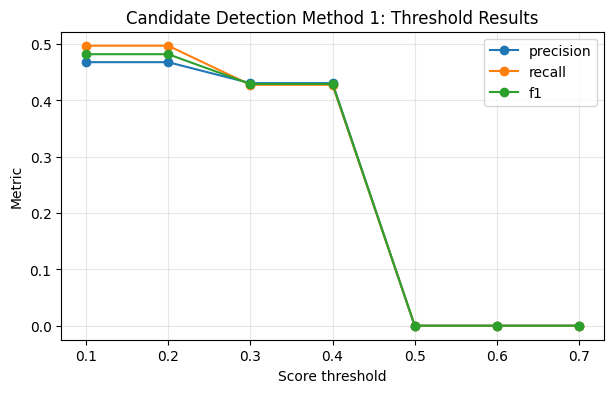

In [ ]:
# Plot threshold results.
plt.figure(figsize=(7, 4))
plt.plot(threshold_results["threshold"], threshold_results["precision"], marker="o", label="precision")
plt.plot(threshold_results["threshold"], threshold_results["recall"], marker="o", label="recall")
plt.plot(threshold_results["threshold"], threshold_results["f1"], marker="o", label="f1")
plt.xlabel("Score threshold")
plt.ylabel("Metric")
plt.title("Candidate Detection Method 1: Threshold Results")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

{'threshold': 0.2, 'TP': 3480, 'FP': 3955, 'FN': 3518, 'TN': 40198}


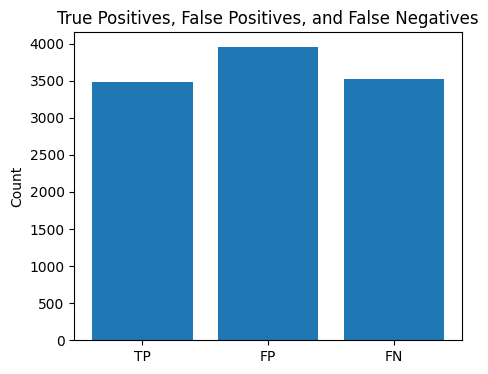

In [ ]:
# Pick a working threshold. Since this is a first-pass filter, start with a recall-friendly threshold.
chosen_threshold = 0.20
cand_df["predicted"] = (cand_df["method1_score"] >= chosen_threshold).astype(int)

cm = confusion_matrix(cand_df["is_gold"], cand_df["predicted"], labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
print({"threshold": chosen_threshold, "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn)})

plt.figure(figsize=(5, 4))
plt.bar(["TP", "FP", "FN"], [tp, fp, fn])
plt.title("True Positives, False Positives, and False Negatives")
plt.ylabel("Count")
plt.show()

{'threshold': 0.5, 'TP': 0, 'FP': 0, 'FN': 6998, 'TN': 44153}


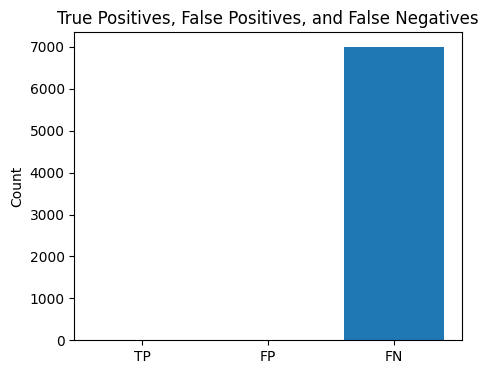

In [ ]:
# Pick a working threshold. Since this is a first-pass filter, start with a recall-friendly threshold.
chosen_threshold = 0.50
cand_df["predicted"] = (cand_df["method1_score"] >= chosen_threshold).astype(int)

cm = confusion_matrix(cand_df["is_gold"], cand_df["predicted"], labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
print({"threshold": chosen_threshold, "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn)})

plt.figure(figsize=(5, 4))
plt.bar(["TP", "FP", "FN"], [tp, fp, fn])
plt.title("True Positives, False Positives, and False Negatives")
plt.ylabel("Count")
plt.show()

In [ ]:
# Inspect examples. This is the main error-analysis step.
true_positives = cand_df[(cand_df["is_gold"] == 1) & (cand_df["predicted"] == 1)].sort_values("method1_score", ascending=False)
false_positives = cand_df[(cand_df["is_gold"] == 0) & (cand_df["predicted"] == 1)].sort_values("method1_score", ascending=False)
false_negatives = cand_df[(cand_df["is_gold"] == 1) & (cand_df["predicted"] == 0)].sort_values("method1_score", ascending=True)

print("True positives")
display(true_positives[["candidate", "method1_score", "surface_score", "sentence", "gold_terms"]].head(10))

print("False positives")
display(false_positives[["candidate", "method1_score", "surface_score", "sentence", "gold_terms"]].head(10))

print("False negatives")
display(false_negatives[["candidate", "method1_score", "surface_score", "sentence", "gold_terms"]].head(10))


True positives


,candidate,method1_score,surface_score,sentence,gold_terms


False positives


,candidate,method1_score,surface_score,sentence,gold_terms


False negatives


,candidate,method1_score,surface_score,sentence,gold_terms
25314,mid,0.0,0.0,"Mate, this vibe is straight mid 😩 😤😭",[mid]
25299,sus,0.0,0.0,"Dude, pull up or stay sus 🫡💀 🫠🫠🥹",[sus]
25292,yikes,0.0,0.0,"Homie, big yikes 😬💀 😤⏰🔥",[yikes]
25280,whole squad,0.0,0.0,"Fam, whole squad waitin’ ⏰🔥 ⏰","[whole squad, waitin’]"
25279,waitin,0.0,0.0,"Fam, whole squad waitin’ ⏰🔥 ⏰","[whole squad, waitin’]"
25257,yikes,0.0,0.0,"Yo, big yikes 😬💀 😤",[yikes]
25250,touch some grass,0.0,0.0,"Mate, touch some grass 🫠 😂🗿",[touch some grass]
25220,fold,0.0,0.0,"Bro, IRL you fold faster than a Walmart chair ...","[fold, IRL]"
25457,sus,0.0,0.0,"Mate, pull up or stay sus 🫡💀 🗿",[sus]
25414,fold,0.0,0.0,"Dude, IRL you fold faster than a Walmart chair...","[fold, IRL]"


In [ ]:
# Make a ranked list of unique candidate terms.
term_ranking = (
    cand_df.groupby("candidate_norm", as_index=False)
    .agg(
        example_candidate=("candidate", "first"),
        max_score=("method1_score", "max"),
        mean_score=("method1_score", "mean"),
        surface_score=("surface_score", "max"),
        gold_count=("is_gold", "sum"),
        example_sentence=("sentence", "first"),
    )
    .sort_values("max_score", ascending=False)
)

term_ranking.head(25)


,candidate_norm,example_candidate,max_score,mean_score,surface_score,gold_count,example_sentence
23,ghosted again,ghosted again,0.428571,0.428571,0.428571,0,"Bro, you ghosted again 😭💀 💎😤"
17,flexin,flexin,0.428571,0.428571,0.428571,503,"Bro, lowkey flexin’ 💎🔥 🥹🥹"
9,cappin,cappin,0.428571,0.428571,0.428571,503,"Fam, stop cappin’, lowkey annoyed 😤 🔥😂🥹"
34,lowkey,lowkey,0.428571,0.428571,0.428571,1006,"Bro, lowkey flexin’ 💎🔥 🥹🥹"
22,ghosted,ghosted,0.428571,0.428571,0.428571,482,"Bro, you ghosted again 😭💀 💎😤"
53,skibidi outta here,skibidi outta here,0.428571,0.428571,0.428571,500,"Bro, skibidi outta here, sigma style 🗿🔥 🫠"
61,stop cappin,stop cappin,0.428571,0.428571,0.428571,0,"Fam, stop cappin’, lowkey annoyed 😤 🔥😂🥹"
51,skibidi,skibidi,0.428571,0.428571,0.428571,0,"Bro, skibidi outta here, sigma style 🗿🔥 🫠"
52,skibidi outta,skibidi outta,0.428571,0.428571,0.428571,0,"Bro, skibidi outta here, sigma style 🗿🔥 🫠"
36,lowkey flexin,lowkey flexin,0.428571,0.428571,0.428571,0,"Bro, lowkey flexin’ 💎🔥 🥹🥹"


In [ ]:
# Save outputs.
out_dir = "candidate_detection_method1_outputs"
os.makedirs(out_dir, exist_ok=True)

cand_df.to_csv(f"{out_dir}/candidate_occurrence_scores.csv", index=False)
term_ranking.to_csv(f"{out_dir}/term_ranking.csv", index=False)
threshold_results.to_csv(f"{out_dir}/threshold_results.csv", index=False)

summary = {
    "num_rows": int(len(df)),
    "num_candidate_occurrences": int(len(cand_df)),
    "chosen_threshold": float(chosen_threshold),
    "true_positives": int(tp),
    "false_positives": int(fp),
    "false_negatives": int(fn),
    "true_negatives": int(tn),
}
with open(f"{out_dir}/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

summary

{'num_rows': 5000,
 'num_candidate_occurrences': 51151,
 'chosen_threshold': 0.5,
 'true_positives': 0,
 'false_positives': 0,
 'false_negatives': 6998,
 'true_negatives': 44153}

6/7/2026 UPDATE:

Summary of changes:
- Emojis are no longer counted as either gold terms or candidates. All gold terms and candidates are text only.
- Phrases with commas are no longer considered as candidates

Effects:
- False positive rate for 0.3 threshold dropped by 5000.

The high rate remains due to our candidate detection process. Since we are looking for phrases (which are included as acceptable gold terms), we sometimes build chunks of specialized language that stack 2+ slang terms together. These chunks then receive high scores but they are not considered valid gold_terms (phrases) so they are dismissed as false positives. This is a hard issue to resolve since we haven't defined words yet to be able to chain meaning together into one phrase. Instead we brute force and check the possibilities until something sticks. This is likely to be the lowest possible FP rate without defining terms.

- Precision and F1 have a greater increase on threshold 0.5.

It still stands that recall does not change until THR=0.5. Overall, there is little change to our metrics when we remove emojis entirely from the process.

- Removing commas has further dropped our FP rate by approximately 10,000.
- Removing commas has also increased overall precision and F1 score.



## Quick notes to fill in

Write a few bullets here after you run the notebook:

- Top terms that looked correct:
- False positives you noticed:
- False negatives you noticed:
- Threshold you would use and why:
- One change you would try next:

TOP CORRECT TERMS:
  - 💀
  - Bruh, lowkey
  - Yo, lowkey
  - Bro, you ghosted
  - Bruh, lowkey flexin

*Note: Emojis are all grouped together in the top row. The remaining rows below contain specialized phrases/terms. The highest ones contain multiple instances of slang in a single phrase.

FALSE POSITIVES:
- 💀
- 😩
- 💀
- ⏰
- 😭

*Note: Most, or all false positives are emojis. Emojis are technically specialized terms, but we need to discuss if they will fall under this category. Our code treats them as such where they are rewarded a higher prediction score. The fault is that they are being labeled as NOT gold terms earlier in the code. This affects our rate by identifying more false positives than there actually is. To fix: gold_term identification. Else, we fix the code to not reward emojis such high prediction scores.

FALSE NEGATIVES:

*Note: No false negatives were found. The threshold selected is so low, that most cases are identified as slang. Non-slang is either correctly identified or incorrectly identified as slang. The fault in this threshold has to do with the classification of slang terms.

THRESHOLD TO USE:

  I would personally use 0.3 as we've already done so. This is because our scenario requires more recall, where we minimize cases in which we overlook slang. This is especially true since we will be layering 3 additional detection filters after this method. If we'd like to improve precision, we can aim for a value just above 0.4, such as 0.43 where we see precision and F1 increase with only a slight drop off in recall.

  I'm still concerned regarding the high false positive rate for emojis. Changing their ground truth value to be is_gold may drastically affect our metrics.
  

ONE CHANGE TO TRY NEXT:

I'd like to fix the emojis is_gold ground truth value and run back metrics to see how it affects thresholds, precision, and recall.